# IEEE Fraud Detection — Production-Quality Preprocessing Pipeline

**Notebook Structure:**
1. Imports & Configuration
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Cleaning (drop high-missing columns, remove leakage/ID columns)
5. Feature Engineering (BEFORE split)
6. Train–Test Split (stratified)
7. Preprocessing Pipeline (ColumnTransformer + imblearn Pipeline + SMOTE)
8. Final Processed Datasets
9. Baseline Model & Evaluation

## 1. Imports & Configuration

In [1]:
# ── Standard Library ────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)

# ── Imbalanced-learn ────────────────────────────────────────────────────────
# IMPORTANT: use imblearn.pipeline, NOT sklearn.pipeline, so SMOTE is
# aware it must run fit_resample (not fit_transform) internally.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ── Global plot settings ────────────────────────────────────────────────────
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading

In [2]:
DATA_PATH = 'ieee_fraud_detection_pipeline_features.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# Work on a copy; preserve df_raw for reference
df = df_raw.copy()

print(f'Dataset shape: {df.shape}')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Dataset shape: (590540, 72)
Memory usage : 518.2 MB


In [3]:
# Quick structural overview
df.head(5).T

,0,1,2,3,4
transaction_id,3025493,3025500,3025502,3025504,3025505
transaction_dt,944517,944558,944587,944613,944622
transaction_ts,2017-12-10 22:21:57,2017-12-10 22:22:38,2017-12-10 22:23:07,2017-12-10 22:23:33,2017-12-10 22:23:42
transaction_amt,50.0,100.0,150.0,50.0,50.0
log_amt,3.931826,4.615121,5.01728,3.931826,3.931826
...,...,...,...,...,...
card1_historical_fraud_rate,0.049306,0.0,0.056287,0.04342,0.034002
email_txn_count,322.0,36998.0,228355.0,228355.0,228355.0
email_historical_fraud_rate,0.018634,0.023217,0.043542,0.043542,0.043542
is_high_risk_product,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 72 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               590540 non-null  int64  
 1   transaction_dt               590540 non-null  int64  
 2   transaction_ts               590540 non-null  object 
 3   transaction_amt              590540 non-null  float64
 4   log_amt                      590540 non-null  float64
 5   hour_of_day                  590540 non-null  int64  
 6   day_of_week                  590540 non-null  int64  
 7   product_cd                   590540 non-null  object 
 8   has_identity                 590540 non-null  int64  
 9   is_fraud                     590540 non-null  int64  
 10  card1                        590540 non-null  int64  
 11  card2                        581607 non-null  float64
 12  card3                        588975 non-null  float64
 13 

In [27]:
df.columns

Index(['transaction_amt', 'log_amt', 'hour_of_day', 'day_of_week',
       'product_cd', 'has_identity', 'is_fraud', 'card1', 'card2', 'card3',
       'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1',
       'purchaser_email_domain', 'recipient_email_domain', 'C1', 'C2', 'C3',
       'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
       'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1_enc', 'M2_enc',
       'M3_enc', 'M4_enc', 'M5_enc', 'M6_enc', 'M7_enc', 'M8_enc', 'M9_enc',
       'id_01', 'id_02', 'id_05', 'id_06', 'id_11', 'id_13', 'id_17', 'id_19',
       'id_20', 'device_type', 'card1_txn_count', 'card1_avg_amt',
       'card1_historical_fraud_rate', 'email_txn_count',
       'email_historical_fraud_rate', 'is_high_risk_product',
       'amt_vs_card_avg_ratio', 'is_night'],
      dtype='object')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,590540.0,3.282270e+06,1.704744e+05,2.987000e+06,3.134635e+06,3.282270e+06,3.429904e+06,3.577539e+06
transaction_dt,590540.0,7.372311e+06,4.617224e+06,8.640000e+04,3.027058e+06,7.306528e+06,1.124662e+07,1.581113e+07
transaction_amt,590540.0,1.350272e+02,2.391625e+02,2.510000e-01,4.332100e+01,6.876900e+01,1.250000e+02,3.193739e+04
log_amt,590540.0,4.382960e+00,9.371828e-01,2.239432e-01,3.791459e+00,4.245190e+00,4.836282e+00,1.037156e+01
hour_of_day,590540.0,1.386192e+01,7.607152e+00,0.000000e+00,6.000000e+00,1.600000e+01,2.000000e+01,2.300000e+01
...,...,...,...,...,...,...,...,...
card1_historical_fraud_rate,590540.0,3.499001e-02,6.429108e-02,0.000000e+00,3.365385e-03,1.700539e-02,3.878648e-02,1.000000e+00
email_txn_count,496084.0,1.345688e+05,9.112841e+04,3.200000e+01,4.525000e+04,1.009340e+05,2.283550e+05,2.283550e+05
email_historical_fraud_rate,496084.0,3.602817e-02,1.564856e-02,0.000000e+00,2.275745e-02,4.354185e-02,4.354185e-02,4.078947e-01
is_high_risk_product,590540.0,7.445220e-01,4.361299e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## 3. Exploratory Data Analysis

### 3.1 Target Distribution — `is_fraud`

Fraud transactions:        20,663  (3.50%)
Legitimate transactions:  569,877  (96.50%)
Class ratio (legit:fraud): 28:1


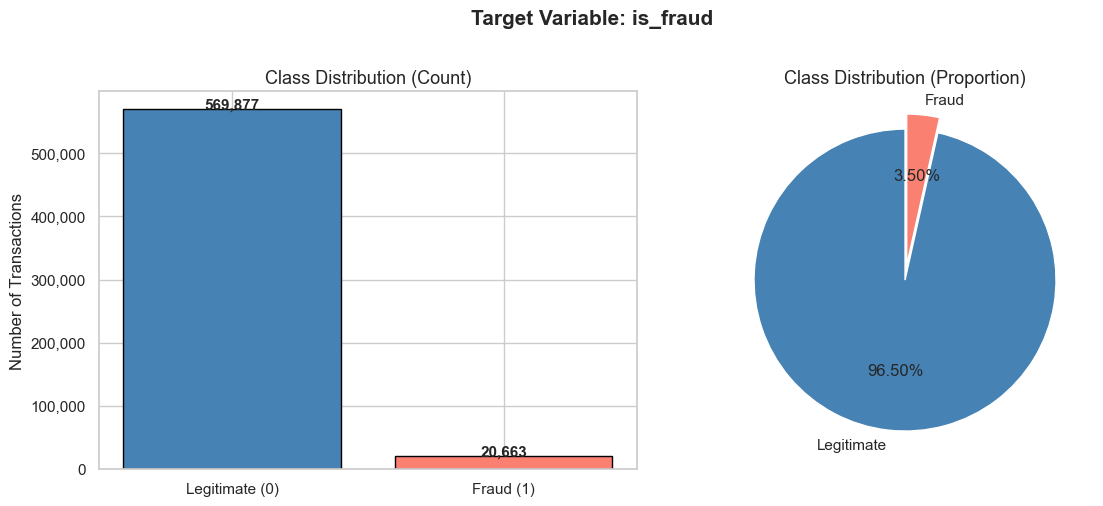

In [6]:
# ── FIX: use is_fraud as target, NOT is_high_risk_product ───────────────────
fraud_rate   = df['is_fraud'].mean()
fraud_count  = df['is_fraud'].sum()
legit_count  = len(df) - fraud_count

print(f'Fraud transactions:      {fraud_count:>8,.0f}  ({fraud_rate:.2%})')
print(f'Legitimate transactions: {legit_count:>8,.0f}  ({1 - fraud_rate:.2%})')
print(f'Class ratio (legit:fraud): {legit_count / fraud_count:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
                   [legit_count, fraud_count],
                   color=['steelblue', 'salmon'], edgecolor='black')
for bar, val in zip(bars, [legit_count, fraud_count]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie([legit_count, fraud_count],
            labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%',
            colors=['steelblue', 'salmon'],
            startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('Target Variable: is_fraud', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Missing Value Analysis

Columns with missing values: 42


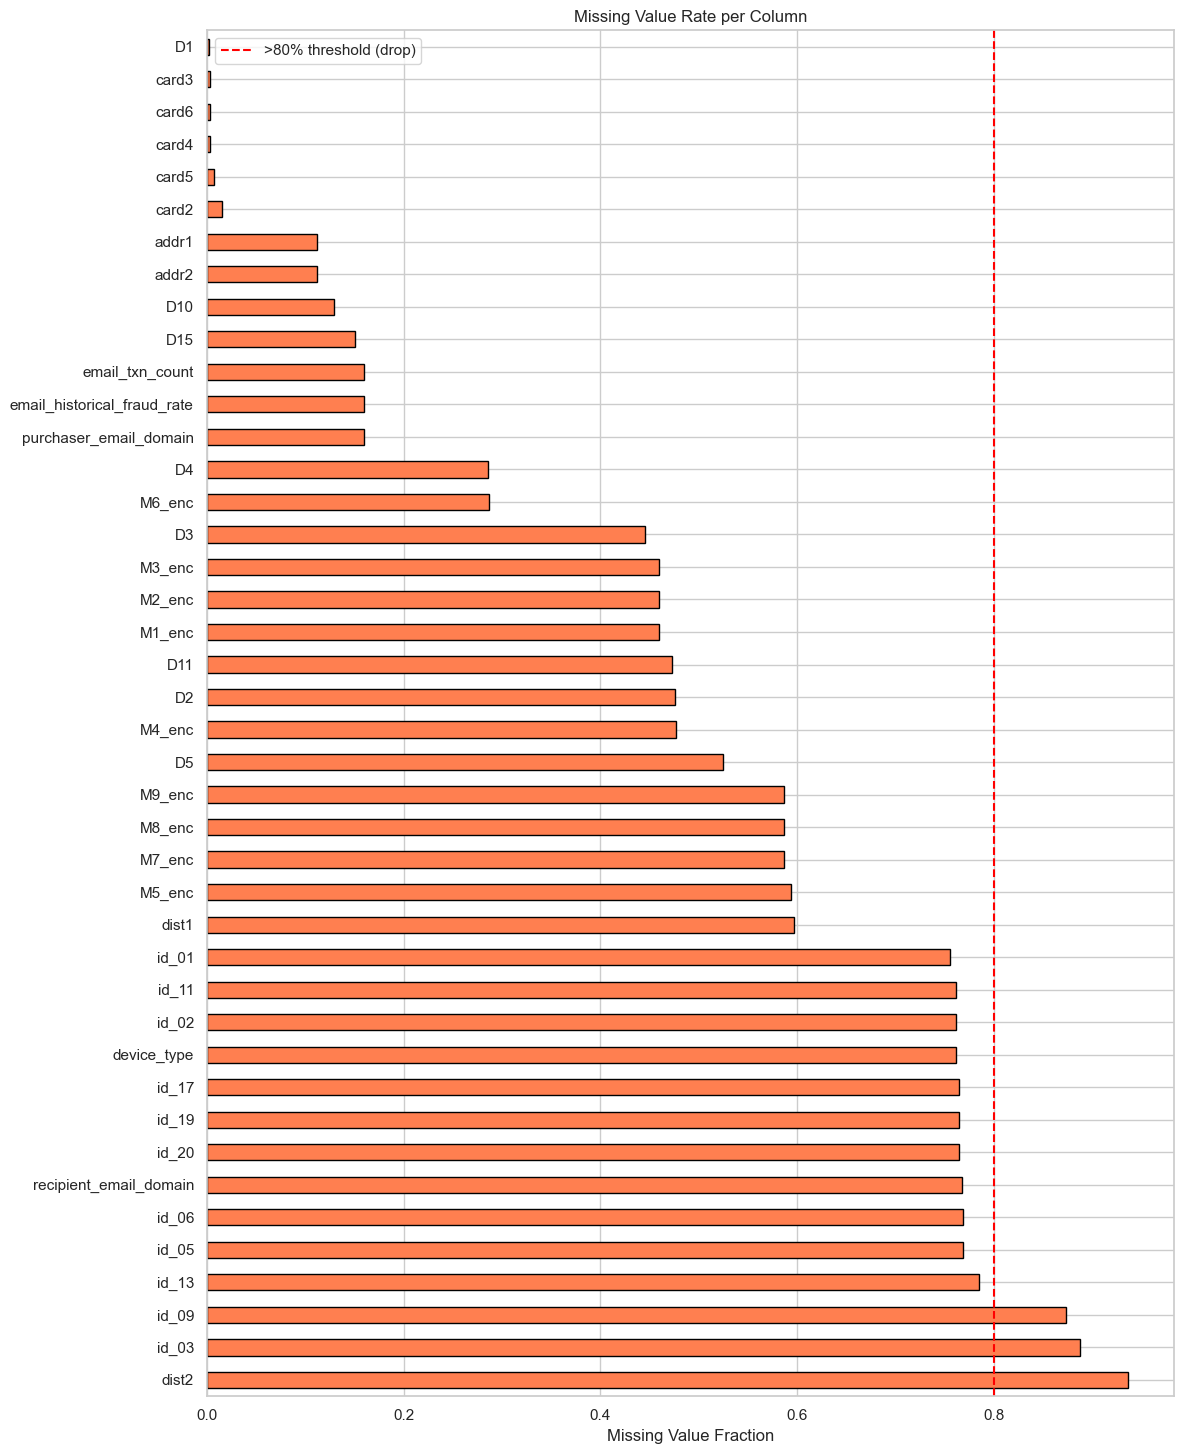

In [7]:
null_pct = df.isnull().mean().sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print(f'Columns with missing values: {len(null_pct)}')

plt.figure(figsize=(12, max(6, len(null_pct) * 0.35)))
null_pct.plot(kind='barh', color='coral', edgecolor='black')
plt.axvline(0.8, color='red', linestyle='--', linewidth=1.5, label='>80% threshold (drop)')
plt.xlabel('Missing Value Fraction')
plt.title('Missing Value Rate per Column')
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Transaction Amount Distribution

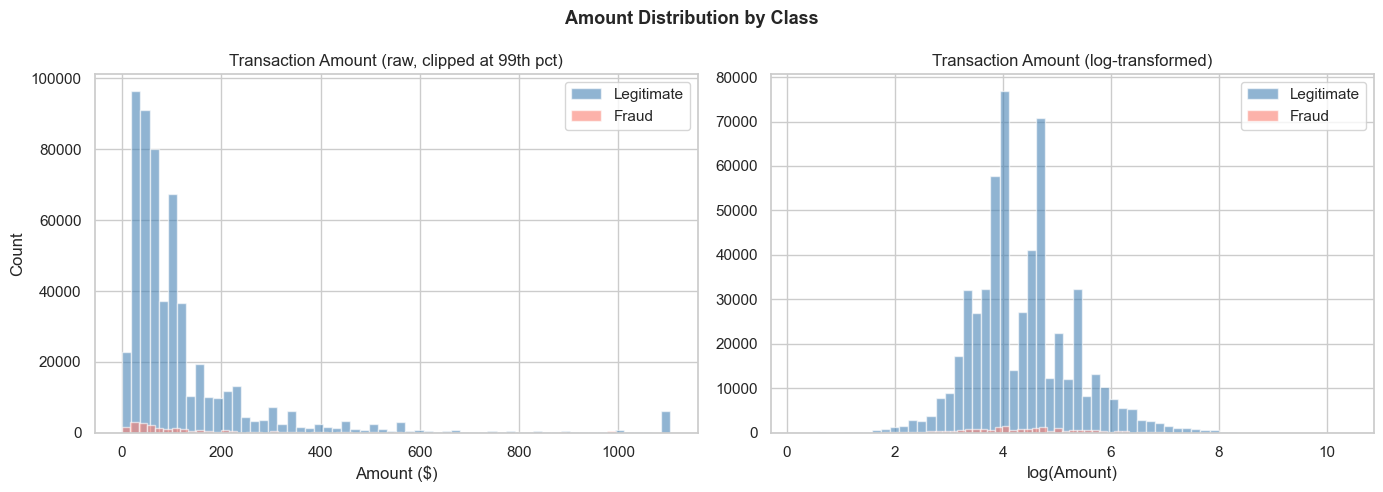

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, colour, data in [
    ('Legitimate', 'steelblue', df[df['is_fraud'] == 0]['transaction_amt']),
    ('Fraud',      'salmon',    df[df['is_fraud'] == 1]['transaction_amt'])
]:
    axes[0].hist(data.clip(upper=data.quantile(0.99)),
                 bins=60, alpha=0.6, label=label, color=colour, edgecolor='white')

axes[0].set_title('Transaction Amount (raw, clipped at 99th pct)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

for label, colour, data in [
    ('Legitimate', 'steelblue', df[df['is_fraud'] == 0]['log_amt']),
    ('Fraud',      'salmon',    df[df['is_fraud'] == 1]['log_amt'])
]:
    axes[1].hist(data, bins=60, alpha=0.6, label=label, color=colour, edgecolor='white')

axes[1].set_title('Transaction Amount (log-transformed)')
axes[1].set_xlabel('log(Amount)')
axes[1].legend()

plt.suptitle('Amount Distribution by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Fraud Rate by Categorical Features

In [9]:
# ── FIX: exclude transaction_ts from categorical EDA ─────────────────────────
# transaction_ts is a raw timestamp — including it in a fraud-rate groupby
# leaks temporal ordering (each unique timestamp trivially predicts fraud)
# and is not a real categorical predictor.
safe_cat_cols = [c for c in df.select_dtypes(include='object').columns
                 if c not in ('transaction_ts',)]

print(f'Categorical columns for EDA: {safe_cat_cols}\n')

for col in safe_cat_cols:
    fraud_rate_by_cat = (
        df.groupby(col)['is_fraud'].mean()
          .sort_values(ascending=False)
          .head(10)
    )
    print(f'{col} — top fraud rates:')
    print(fraud_rate_by_cat.to_string())
    print()

Categorical columns for EDA: ['product_cd', 'card4', 'card6', 'purchaser_email_domain', 'recipient_email_domain', 'device_type']

product_cd — top fraud rates:
product_cd
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399

card4 — top fraud rates:
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698

card6 — top fraud rates:
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000

purchaser_email_domain — top fraud rates:
purchaser_email_domain
protonmail.com    0.407895
mail.com          0.189624
outlook.es        0.130137
aim.com           0.126984
outlook.com       0.094584
hotmail.es        0.065574
live.com.mx       0.054740
hotmail.com       0.052950
gmail.com         0.043542
yahoo.fr          0.034965

recipient_email_domain — top fraud rates:
recipient_email_domain
protonmail.com    0.951220
mail.com          0.377049
netzero.net

### 3.5 Time-Based Fraud Patterns

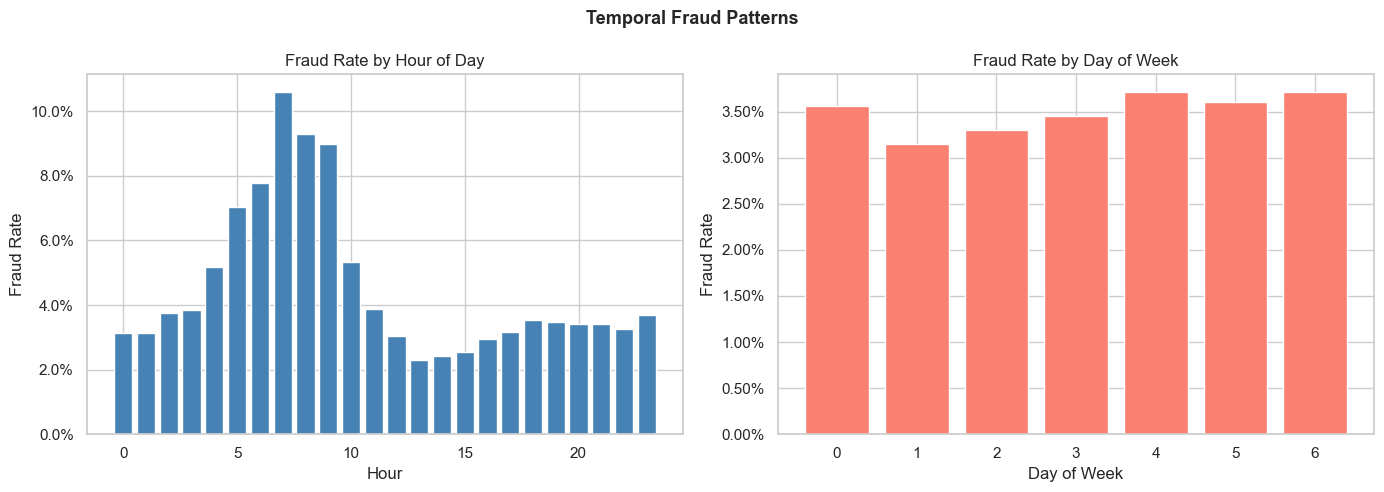

In [10]:
# hour_of_day and day_of_week are already present in the dataset.
# We visualise them here for insight BEFORE dropping transaction_ts.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_fraud = df.groupby('hour_of_day')['is_fraud'].mean()
axes[0].bar(hour_fraud.index, hour_fraud.values, color='steelblue', edgecolor='white')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_fraud = df.groupby('day_of_week')['is_fraud'].mean()
axes[1].bar(dow_fraud.index, dow_fraud.values, color='salmon', edgecolor='white')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Temporal Fraud Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [11]:
# ── Step 4.1: Drop columns with > 80% missing values ────────────────────────
# NOTE: Dropping *columns* (not imputing) on the full dataset is acceptable
# because we are removing features entirely — no statistics are fitted here.
null_pct_all = df.isnull().mean()
high_missing_cols = null_pct_all[null_pct_all > 0.8].index.tolist()
print(f'Columns dropped (>80% missing): {len(high_missing_cols)}')
print(high_missing_cols)

df = df.drop(columns=high_missing_cols)
print(f'Shape after high-missing drop: {df.shape}')

Columns dropped (>80% missing): 3
['dist2', 'id_03', 'id_09']
Shape after high-missing drop: (590540, 69)


In [12]:
# ── Step 4.2: Remove leakage and identifier columns ──────────────────────────
#
# transaction_id   — row identifier; carries no predictive information
# transaction_dt   — raw elapsed-seconds field; temporal ordering leaks
#                    future fraud patterns into the model. Time features
#                    (hour_of_day, day_of_week, is_night) are extracted
#                    from transaction_ts FIRST (see Feature Engineering),
#                    then transaction_ts itself is also dropped.
# transaction_ts   — raw timestamp string; leaks exact ordering.
#                    We extract useful features before dropping.

LEAKAGE_COLS = ['transaction_id', 'transaction_dt', 'transaction_ts']
existing_leakage = [c for c in LEAKAGE_COLS if c in df.columns]
print(f'Leakage / ID columns to remove: {existing_leakage}')

Leakage / ID columns to remove: ['transaction_id', 'transaction_dt', 'transaction_ts']


## 5. Feature Engineering (BEFORE Train–Test Split)

In [13]:
# ── Step 5.1: Extract time-based features from transaction_ts ─────────────
# We do this BEFORE dropping the column so the information is preserved.
# hour_of_day and day_of_week are already present; we add is_night.

if 'transaction_ts' in df.columns:
    ts = pd.to_datetime(df['transaction_ts'], errors='coerce')

    # Overwrite / confirm existing time columns (in case they differ)
    df['hour_of_day']  = ts.dt.hour
    df['day_of_week']  = ts.dt.dayofweek    # 0=Monday … 6=Sunday

    # New feature: is_night (midnight–6 AM has higher fraud rates per EDA)
    df['is_night'] = (df['hour_of_day'].between(0, 5)).astype(int)

    print('Extracted: hour_of_day, day_of_week, is_night')
else:
    print('transaction_ts not found — skipping time extraction.')

Extracted: hour_of_day, day_of_week, is_night


In [14]:
# ── Step 5.2: Now drop leakage / ID columns ──────────────────────────────────
df = df.drop(columns=existing_leakage, errors='ignore')
print(f'Shape after leakage drop: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')

Shape after leakage drop: (590540, 67)
Remaining columns: ['transaction_amt', 'log_amt', 'hour_of_day', 'day_of_week', 'product_cd', 'has_identity', 'is_fraud', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'purchaser_email_domain', 'recipient_email_domain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1_enc', 'M2_enc', 'M3_enc', 'M4_enc', 'M5_enc', 'M6_enc', 'M7_enc', 'M8_enc', 'M9_enc', 'id_01', 'id_02', 'id_05', 'id_06', 'id_11', 'id_13', 'id_17', 'id_19', 'id_20', 'device_type', 'card1_txn_count', 'card1_avg_amt', 'card1_historical_fraud_rate', 'email_txn_count', 'email_historical_fraud_rate', 'is_high_risk_product', 'amt_vs_card_avg_ratio', 'is_night']


In [15]:
# ── Step 5.3: Verify target is correct ──────────────────────────────────────
assert 'is_fraud' in df.columns, "ERROR: target column 'is_fraud' not found!"
assert df['is_fraud'].nunique() == 2, "ERROR: is_fraud should be binary!"

print(f"Target column 'is_fraud' verified. Value counts:")
print(df['is_fraud'].value_counts())

Target column 'is_fraud' verified. Value counts:
is_fraud
0    569877
1     20663
Name: count, dtype: int64


In [16]:
# ── Step 5.4: Separate features and target ──────────────────────────────────
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (590540, 66)
y shape: (590540,)


In [17]:
# ── Step 5.5: Detect column types AFTER all feature engineering ─────────────
# Column type detection must happen on X (features only, leakage removed)
# and BEFORE the train/test split so the pipeline column lists are consistent.

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Numerical columns (57): ['transaction_amt', 'log_amt', 'has_identity', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1_enc', 'M2_enc', 'M3_enc', 'M4_enc', 'M5_enc', 'M6_enc', 'M7_enc', 'M8_enc', 'M9_enc', 'id_01', 'id_02', 'id_05', 'id_06', 'id_11', 'id_13', 'id_17', 'id_19', 'id_20', 'card1_txn_count', 'card1_avg_amt', 'card1_historical_fraud_rate', 'email_txn_count', 'email_historical_fraud_rate', 'is_high_risk_product', 'amt_vs_card_avg_ratio']
Categorical columns (6): ['product_cd', 'card4', 'card6', 'purchaser_email_domain', 'recipient_email_domain', 'device_type']


## 6. Train–Test Split

In [18]:
# ── Single, stratified split ─────────────────────────────────────────────────
# stratify=y preserves the fraud / legitimate ratio in both sets.
# All .fit() / .fit_transform() calls will happen ONLY on X_train.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Training set   : {X_train.shape}  | Fraud rate: {y_train.mean():.4%}')
print(f'Test set       : {X_test.shape}   | Fraud rate: {y_test.mean():.4%}')

Training set   : (472432, 66)  | Fraud rate: 3.4989%
Test set       : (118108, 66)   | Fraud rate: 3.4993%


## 7. Preprocessing Pipeline (ColumnTransformer + SMOTE)

In [19]:
# ── Step 7.1: Numerical sub-pipeline ────────────────────────────────────────
# median imputation is robust to outliers; StandardScaler normalises scale.
num_pipeline = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Step 7.2: Categorical sub-pipeline ──────────────────────────────────────
# most_frequent imputation for missing category codes;
# handle_unknown='ignore' silently encodes unseen categories as all-zeros
# at inference time — prevents pipeline failures on production data.
cat_pipeline = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Step 7.3: Column transformer ────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ],
    remainder='drop'    # drop any columns not listed above
)

print('Preprocessor built.')
print(f'  Numerical features : {len(num_cols)}')
print(f'  Categorical features: {len(cat_cols)}')

Preprocessor built.
  Numerical features : 57
  Categorical features: 6


In [20]:
# ── Step 7.4: Fit preprocessor on TRAINING DATA ONLY ────────────────────────
# fit_transform on X_train   → learns imputation medians, scaler stats,
#                               OHE vocabulary entirely from training data.
# transform on X_test        → applies the SAME learned statistics to test
#                               data (no data leakage).

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'X_train_processed shape: {X_train_processed.shape}')
print(f'X_test_processed shape : {X_test_processed.shape}')

# Verify no NaN remains
assert np.isnan(X_train_processed).sum() == 0, 'NaN detected in X_train_processed!'
assert np.isnan(X_test_processed).sum()  == 0, 'NaN detected in X_test_processed!'
print('No NaN values detected — preprocessing verified.')

X_train_processed shape: (472432, 191)
X_test_processed shape : (118108, 191)
No NaN values detected — preprocessing verified.


## 8. SMOTE — Applied Only on Training Data

In [21]:
# ── SMOTE on training set only ───────────────────────────────────────────────
# CRITICAL: SMOTE must NEVER see test data.
# We apply it after preprocessing so synthetic samples are generated
# in the scaled/encoded feature space (numerically stable).
#
# fit_resample() both fits the SMOTE model and returns the resampled arrays.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train
)

print('After SMOTE resampling:')
print(f'  X_train_resampled shape : {X_train_resampled.shape}')
print(f'  y_train_resampled counts: {pd.Series(y_train_resampled).value_counts().to_dict()}')
print(f'  Fraud rate in resampled : {y_train_resampled.mean():.4%}')

  File "c:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


After SMOTE resampling:
  X_train_resampled shape : (911804, 191)
  y_train_resampled counts: {0: 455902, 1: 455902}
  Fraud rate in resampled : 50.0000%


## 9. Final Processed Datasets — Summary

In [22]:
# ── Final dataset shapes and class distributions ─────────────────────────────
print('=' * 55)
print('FINAL PROCESSED DATASETS')
print('=' * 55)
print(f'X_train_processed  : {X_train_processed.shape}')
print(f'X_test_processed   : {X_test_processed.shape}')
print(f'y_train            : {y_train.shape}  (original)')
print(f'y_test             : {y_test.shape}')
print()
print(f'X_train_resampled  : {X_train_resampled.shape}  (post-SMOTE)')
print(f'y_train_resampled  : {y_train_resampled.shape}  (post-SMOTE)')
print()
print('Class distribution — y_train (original):')
print(pd.Series(y_train).value_counts().rename({0: 'Legit', 1: 'Fraud'}).to_string())
print()
print('Class distribution — y_train_resampled (post-SMOTE):')
print(pd.Series(y_train_resampled).value_counts().rename({0: 'Legit', 1: 'Fraud'}).to_string())
print()
print('Class distribution — y_test:')
print(pd.Series(y_test).value_counts().rename({0: 'Legit', 1: 'Fraud'}).to_string())
print('=' * 55)

FINAL PROCESSED DATASETS
X_train_processed  : (472432, 191)
X_test_processed   : (118108, 191)
y_train            : (472432,)  (original)
y_test             : (118108,)

X_train_resampled  : (911804, 191)  (post-SMOTE)
y_train_resampled  : (911804,)  (post-SMOTE)

Class distribution — y_train (original):
is_fraud
Legit    455902
Fraud     16530

Class distribution — y_train_resampled (post-SMOTE):
is_fraud
Legit    455902
Fraud    455902

Class distribution — y_test:
is_fraud
Legit    113975
Fraud      4133


## 10. Baseline Model — Random Forest

In [23]:
# ── Train on SMOTE-resampled training data ───────────────────────────────────
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)
print('Model trained.')

Model trained.


In [24]:
# ── Evaluate on the held-out test set ───────────────────────────────────────
# FIX: y_pred was never defined in the original notebook.
# Predictions are made using X_test_processed (preprocessed, not resampled).

y_pred      = model.predict(X_test_processed)
y_pred_prob = model.predict_proba(X_test_processed)[:, 1]

print('Accuracy :', accuracy_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_pred_prob))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

Accuracy : 0.9662935618247706
ROC-AUC  : 0.9373037594520471

Confusion Matrix:
[[111251   2724]
 [  1257   2876]]

Classification Report:
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.98    113975
       Fraud       0.51      0.70      0.59      4133

    accuracy                           0.97    118108
   macro avg       0.75      0.84      0.79    118108
weighted avg       0.97      0.97      0.97    118108



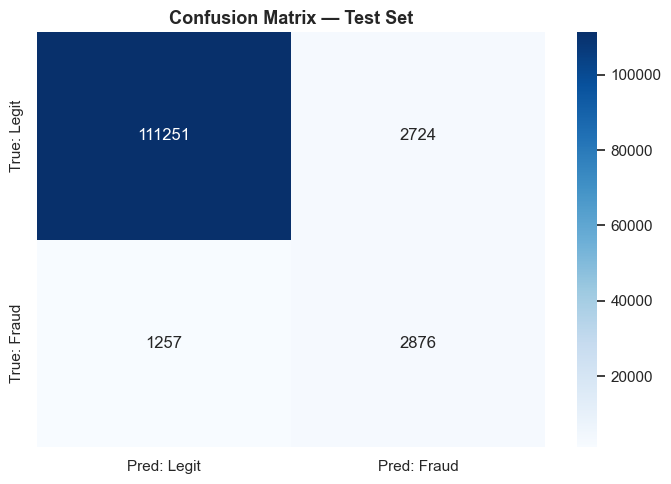

In [25]:
# ── Confusion matrix heatmap ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'])
plt.title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

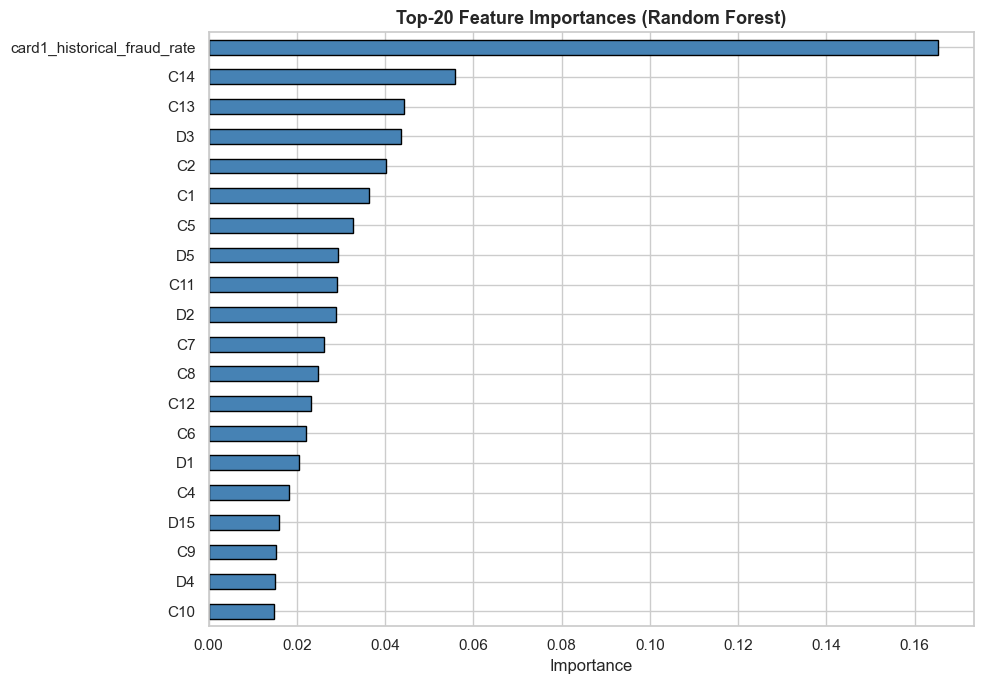

In [26]:
# ── Top-20 Feature Importances ───────────────────────────────────────────────
# Retrieve feature names from the ColumnTransformer
ohe_feature_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

feat_imp = pd.Series(model.feature_importances_, index=all_feature_names)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top-20 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()